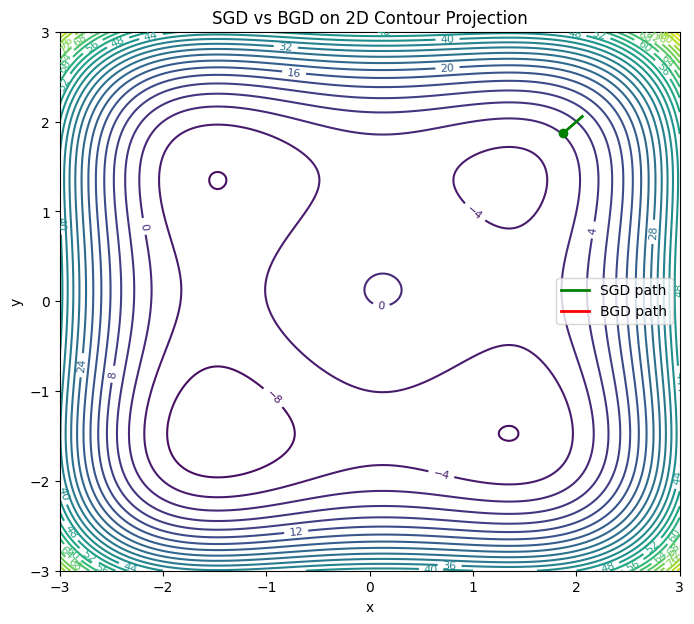

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# =========================
# 3D loss function
# =========================
def f(x, y):
    return x**4 + y**4 - 4*x**2 - 4*y**2 + x + y


def grad_f(x, y):
    gx = 4*x**3 - 8*x + 1
    gy = 4*y**3 - 8*y + 1
    return gx, gy


def sgd_grad(x, y, noise_std=0.8):
    gx, gy = grad_f(x, y)
    gx += np.random.normal(0, noise_std)
    gy += np.random.normal(0, noise_std)
    return gx, gy


# =========================
# Contour grid
# =========================
x_vals = np.linspace(-3, 3, 300)
y_vals = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f(X, Y)

# =========================
# Optimization setup
# =========================
eta = 0.01
epochs = 200

x0, y0 = 2.5, 2.5

# SGD state
x_sgd, y_sgd = x0, y0
sgd_path = []

# BGD state
x_bgd, y_bgd = x0, y0
bgd_path = []

# =========================
# Figure
# =========================
fig, ax = plt.subplots(figsize=(8, 7))

contours = ax.contour(X, Y, Z, levels=30, cmap="viridis")
ax.clabel(contours, inline=True, fontsize=8)

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("SGD vs BGD on 2D Contour Projection")

# Animated objects
sgd_line, = ax.plot([], [], "g-", linewidth=2, label="SGD path")
sgd_point, = ax.plot([], [], "go")

bgd_line, = ax.plot([], [], "r-", linewidth=2, label="BGD path")
bgd_point, = ax.plot([], [], "ro")

ax.legend()

# =========================
# Animation update
# =========================
def update(frame):
    global x_sgd, y_sgd, x_bgd, y_bgd

    # ---- SGD phase (first 50 frames) ----
    if frame < epochs:
        gx, gy = sgd_grad(x_sgd, y_sgd)
        x_sgd -= eta * gx
        y_sgd -= eta * gy
        sgd_path.append((x_sgd, y_sgd))

        path = np.array(sgd_path)
        sgd_line.set_data(path[:, 0], path[:, 1])
        sgd_point.set_data([x_sgd], [y_sgd])

    # ---- BGD phase (next 50 frames) ----
    else:
        gx, gy = grad_f(x_bgd, y_bgd)
        x_bgd -= eta * gx
        y_bgd -= eta * gy
        bgd_path.append((x_bgd, y_bgd))

        path = np.array(bgd_path)
        bgd_line.set_data(path[:, 0], path[:, 1])
        bgd_point.set_data([x_bgd], [y_bgd])

    return sgd_line, sgd_point, bgd_line, bgd_point


# =========================
# Run animation
# =========================
ani = FuncAnimation(
    fig,
    update,
    frames=2 * epochs,
    interval=150,
    blit=True
)

plt.show()
